/opt/miniconda3/envs/nf_geo/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/nf_geo/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/miniconda3/envs/nf_geo/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/nf_geo/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/miniconda3/envs/nf_geo/lib/python3.13/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/opt/miniconda3/envs/nf_geo/lib/python3.13/site-packages/shapely/predicates.py:878: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects

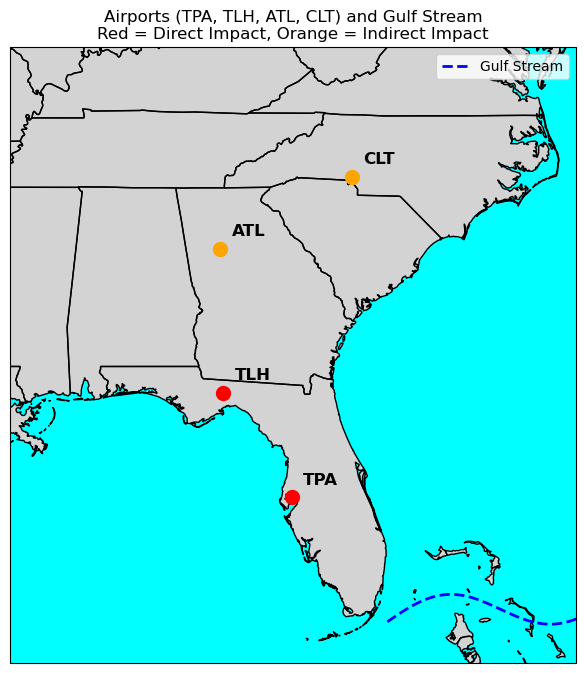

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Airport coordinates
airports = {
    'TPA': (27.9755, -82.5332),
    'TLH': (30.3965, -84.3503),
    'ATL': (33.6407, -84.4277),
    'CLT': (35.2140, -80.9431)
}
colors = {'TPA':'red','TLH':'red','ATL':'orange','CLT':'orange'}

plt.figure(figsize=(12,8))
ax = plt.axes(projection=ccrs.Mercator())
ax.set_extent([-90, -75, 24, 38], crs=ccrs.PlateCarree())

# Add land, ocean, borders
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.OCEAN, facecolor='aqua')
ax.add_feature(cfeature.STATES, edgecolor='black')
ax.add_feature(cfeature.BORDERS, edgecolor='black')

# Plot airports
for code, (lat, lon) in airports.items():
    plt.plot(lon, lat, 'o', color=colors[code], markersize=10, transform=ccrs.PlateCarree())
    plt.text(lon+0.3, lat+0.3, code, fontsize=12, fontweight='bold', transform=ccrs.PlateCarree())

# Approximate Gulf Stream
gulf_lon = np.linspace(-80, -71, 100)
gulf_lat = 25 + 0.1*(gulf_lon+80) + 0.5*np.sin(np.linspace(0,3*np.pi,100))
plt.plot(gulf_lon, gulf_lat, 'b--', linewidth=2, label='Gulf Stream', transform=ccrs.PlateCarree())

plt.legend()
plt.title('Airports (TPA, TLH, ATL, CLT) and Gulf Stream\nRed = Direct Impact, Orange = Indirect Impact')

# Save figure
plt.savefig("neu_airports_gulfstream_map.png", dpi=300, bbox_inches='tight')

plt.show()